# 06 - Advanced PD Modelling

## Credit Risk Modelling Using Logistic Regression

This notebook tests whether nonlinear effects and one motivated interaction improve the baseline logistic PD model from Notebook 04. The baseline remains the benchmark. Model selection uses nested cross-validation within the training partition; the reserved holdout is scored only after the selection rule is applied.

Notebook 03 showed strong risk gradients for utilization and prior delinquency, generally lower default rates at older ages, and irregular income and debt-ratio patterns. The candidate adds piecewise-linear terms for age, log utilization, log debt ratio, log income, and log total delinquencies. It also adds one interaction between log utilization and log delinquencies. Quantile knots are learned inside each training fold. Boundary knots are omitted when they would duplicate the linear term, and delinquency knots use borrowers with nonzero delinquency counts.

Regularized candidates use the same expanded terms and compare Ridge, Lasso, and Elastic Net penalties. The C parameter is tuned by inner cross-validation. No holdout observations enter preprocessing, tuning, or selection.

## 1. Reconstruct the baseline

Load the cleaned data, rebuild the seed 47 split from the saved Notebook 04 model package, and fit the same unpenalized logistic regression on the training partition. Compare the reconstructed coefficients with the saved coefficients before using the package to score the holdout.

In [1]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import chi2
from IPython.display import display
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, "../src")
from model import prepare_data, split_data, scale_data, fit_logit
from model import coefficient_table, predict_pd
from evaluation import discrimination_metrics, calibration_table
from advanced_model import (
    RiskTerms, short_frame, cal_gap, cv_mle, cv_reg, tune_reg, predict_model,
)

DATA_PATH = "../data/processed/cleaned_data.csv"
BASE_PATH = "../models/logistic_regression.pkl"
OUT_PATH = "../models/advanced_pd_model.pkl"
FIG_PATH = "../reports/figures/06_calibration_comparison.png"
SEED = 47

clean_data = pd.read_csv(DATA_PATH)
feat, target = prepare_data(clean_data)
with open(BASE_PATH, "rb") as model_file:
    base_pack = pickle.load(model_file)

train_feat, hold_feat, train_y, hold_y = split_data(
    feat, target, base_pack["seed"]
)
scale, train_base, hold_base = scale_data(train_feat, hold_feat)
base_fit = fit_logit(train_base, train_y)
base_coef = coefficient_table(base_fit)
base_pd = predict_pd(hold_feat, base_pack)
base_metrics = discrimination_metrics(hold_y, base_pd)
base_brier = float(np.mean((base_pd.to_numpy() - hold_y.to_numpy()) ** 2))
base_pack_coef = pd.Series(base_pack["coef"])
coef_diff = float(
    (base_fit.params.reindex(base_pack_coef.index) - base_pack_coef).abs().max()
)

coef_view = base_coef[[
    "coefficient", "std_error", "p_value", "odds_ratio_per_sd",
    "or_ci_lower", "or_ci_upper",
]].round(4)
metric_view = pd.DataFrame({
    "holdout_value": {
        **base_metrics,
        "brier_score": base_brier,
    }
}).round(4)
print(f"Training borrowers: {len(train_y):,}")
print(f"Holdout borrowers: {len(hold_y):,}")
print(f"Seed: {base_pack['seed']}")
print(f"Largest coefficient difference from saved fit: {coef_diff:.3g}")
display(coef_view)
display(metric_view)

Training borrowers: 101,893
Holdout borrowers: 43,669
Seed: 47
Largest coefficient difference from saved fit: 0


,coefficient,std_error,p_value,odds_ratio_per_sd,or_ci_lower,or_ci_upper
const,-2.7407,0.0138,0.0000,0.0645,0.0628,0.0663
age,-0.4545,0.0145,0.0000,0.6348,0.6170,0.6530
RevolvingUtilizationOfUnsecuredLines,-0.0174,0.0185,0.3479,0.9827,0.9477,1.0191
DebtRatio,-0.0212,0.0250,0.3961,0.9790,0.9322,1.0282
LogMonthlyIncome,-0.0170,0.0122,0.1631,0.9831,0.9599,1.0069
TotalDelinquencies,0.1646,0.0103,0.0000,1.1789,1.1553,1.2030
NumberOfOpenCreditLinesAndLoans,-0.0355,0.0151,0.0191,0.9651,0.9369,0.9942
NumberRealEstateLoansOrLines,0.0310,0.0144,0.0308,1.0315,1.0029,1.0609
NumberOfDependents,0.1155,0.0117,0.0000,1.1224,1.0971,1.1484


,holdout_value
roc_auc,0.6484
gini,0.2968
ks,0.2160
pr_auc,0.1214
brier_score,0.0618


## 2. Add nonlinear terms and the interaction

The model retains every baseline predictor, so the baseline is nested within the expanded specification. Log transformations compress the heavy tails in utilization, debt ratio, and delinquency counts. Hinge terms add slope changes at training-sample quartiles. The interaction is centered at its training means; it measures how the utilization relationship changes with delinquency history.

The added coefficients describe changes in slope or joint effects. Their odds ratios are per standard deviation of the transformed term, so they should not be read as standalone borrower-level effects.

In [2]:
short_train = short_frame(train_feat)
short_hold = short_frame(hold_feat)
terms = RiskTerms()
train_terms = terms.fit_transform(short_train)
hold_terms = terms.transform(short_hold)
scale_adv = StandardScaler()
train_adv = pd.DataFrame(
    scale_adv.fit_transform(train_terms),
    columns=train_terms.columns,
    index=train_terms.index,
)
hold_adv = pd.DataFrame(
    scale_adv.transform(hold_terms),
    columns=hold_terms.columns,
    index=hold_terms.index,
)
adv_fit = fit_logit(train_adv, train_y)
adv_hold_design = sm.add_constant(hold_adv, has_constant="add")
adv_pd = adv_fit.predict(adv_hold_design)
adv_coef = coefficient_table(adv_fit)

lr_stat = 2 * (adv_fit.llf - base_fit.llf)
lr_df = int(adv_fit.df_model - base_fit.df_model)
lr_p = chi2.sf(lr_stat, lr_df)
print(f"Expanded predictors: {train_adv.shape[1]}")
print(f"Converged: {adv_fit.mle_retvals['converged']}")
p_text = "<0.001" if lr_p < 0.001 else f"{lr_p:.3g}"
print(f"Likelihood-ratio statistic: {lr_stat:.2f} on {lr_df} df; p={p_text}")
print("Knots learned from the training partition:")
print({key: np.round(val, 3).tolist() for key, val in terms.knots_.items()})
display(adv_coef.round(4))

Expanded predictors: 26
Converged: True
Likelihood-ratio statistic: 10954.38 on 18 df; p=<0.001
Knots learned from the training partition:
{'age': [41.0, 52.0, 62.0], 'util_log': [0.031, 0.147, 0.445], 'debt_log': [0.16, 0.307, 0.572], 'income': [8.247, 8.764, 8.923], 'delinq_log': [0.693, 1.099]}


,coefficient,std_error,z_value,p_value,ci_lower,ci_upper,odds_ratio_per_sd,or_ci_lower,or_ci_upper
const,-3.4081,0.0216,-157.7617,0.0000,-3.4505,-3.3658,0.0331,0.0317,0.0345
age,-0.2499,0.0598,-4.1757,0.0000,-0.3672,-0.1326,0.7789,0.6927,0.8758
util,-0.2845,0.0738,-3.8572,0.0001,-0.4291,-0.1399,0.7524,0.6511,0.8694
debt,-0.0093,0.0324,-0.2871,0.7740,-0.0727,0.0541,0.9908,0.9299,1.0556
income,0.1116,0.0228,4.8960,0.0000,0.0669,0.1563,1.1180,1.0692,1.1691
delinq,-0.2111,0.0140,-15.1132,0.0000,-0.2385,-0.1837,0.8097,0.7878,0.8322
open,0.0433,0.0172,2.5162,0.0119,0.0096,0.0771,1.0443,1.0096,1.0802
estate,0.0959,0.0165,5.8080,0.0000,0.0635,0.1282,1.1006,1.0656,1.1368
dependents,0.0415,0.0141,2.9509,0.0032,0.0139,0.0691,1.0424,1.0140,1.0715
util_log,-2.3090,1.2103,-1.9079,0.0564,-4.6811,0.0631,0.0994,0.0093,1.0651


## 3. Check model diagnostics

The likelihood-ratio test asks whether the added nonlinear and interaction terms improve in-sample fit over the nested baseline. It does not measure out-of-sample improvement. VIF values flag collinearity among the expanded terms; hinge bases often correlate by construction. Influence values are screening signals, not automatic exclusion rules. Near-zero or near-one fitted probabilities are checked as a basic warning for separation.

In [3]:
corr_mat = train_adv.corr().to_numpy()
vif_vals = np.diag(np.linalg.pinv(corr_mat))
vif_tab = pd.DataFrame({
    "predictor": train_adv.columns,
    "vif": vif_vals,
}).sort_values("vif", ascending=False)

train_design = sm.add_constant(train_adv, has_constant="add")
train_pd = adv_fit.predict(train_design)
glm_fit = sm.GLM(
    train_y, train_design, family=sm.families.Binomial()
).fit()
influence = glm_fit.get_influence()
cook_vals = influence.cooks_distance[0]
leverage = influence.hat_matrix_diag
cook_cut = 4 / len(train_y)

print(f"Condition number of expanded design: {np.linalg.cond(train_adv):.1f}")
print(f"VIF values above 10: {(vif_tab['vif'] > 10).sum()}")
print(f"Maximum VIF: {vif_tab['vif'].max():.1f}")
print(f"Fitted PDs below 1e-6: {(train_pd < 1e-6).sum()}")
print(f"Fitted PDs above 1 - 1e-6: {(train_pd > 1 - 1e-6).sum()}")
print(f"Cook's distance above 4/n: {(cook_vals > cook_cut).sum()}")
print(f"Maximum Cook's distance: {cook_vals.max():.4g}")
print(f"Maximum leverage: {leverage.max():.4g}")
display(vif_tab.head(8).round(2))

Condition number of expanded design: 377.0
VIF values above 10: 16
Maximum VIF: 17199.5
Fitted PDs below 1e-6: 10
Fitted PDs above 1 - 1e-6: 0
Cook's distance above 4/n: 6286
Maximum Cook's distance: 0.177
Maximum leverage: 0.2378


,predictor,vif
18,h_debt_1,17199.48
19,h_debt_2,10127.18
9,debt_log,5772.30
15,h_util_1,3741.43
8,util_log,2728.55
20,h_debt_3,1661.87
16,h_util_2,268.76
22,h_inc_2,94.69


## 4. Compare models with nested cross-validation

The outer five folds estimate generalization within the training partition. For each regularized candidate, an inner three-fold search selects C from the documented grid. The same outer folds evaluate the baseline, nonlinear maximum-likelihood model, Ridge, Lasso, and Elastic Net.

Calibration gap is the borrower-weighted mean absolute difference between predicted PD and observed default rate across ten quantile groups. Lower is better. The selection rule is set in advance: an advanced candidate must improve mean outer-fold AUC by at least 0.005, avoid worse Brier score and calibration gap, and exceed baseline AUC in at least four of five folds.

In [4]:
base_cv = cv_mle(train_feat, train_y, seed=SEED)
nonlin_cv = cv_mle(
    train_feat, train_y, nonlinear=True, seed=SEED
)
ridge_cv = cv_reg(train_feat, train_y, "ridge", seed=SEED)
lasso_cv = cv_reg(train_feat, train_y, "lasso", seed=SEED)
enet_cv = cv_reg(train_feat, train_y, "elastic_net", seed=SEED)

cv_tabs = {
    "Baseline Logistic": base_cv,
    "Nonlinear Logistic": nonlin_cv,
    "Ridge Logistic": ridge_cv,
    "Lasso Logistic": lasso_cv,
    "Elastic Net Logistic": enet_cv,
}
interp = {
    "Baseline Logistic": "High",
    "Nonlinear Logistic": "Moderate",
    "Ridge Logistic": "Moderate",
    "Lasso Logistic": "Moderate",
    "Elastic Net Logistic": "Moderate",
}

def cv_row(name, table):
    return {
        "model": name,
        "auc_mean": table["roc_auc"].mean(),
        "auc_sd": table["roc_auc"].std(ddof=1),
        "gini_mean": 2 * table["roc_auc"].mean() - 1,
        "ks_mean": table["ks"].mean(),
        "pr_auc_mean": table["pr_auc"].mean(),
        "brier_mean": table["brier_score"].mean(),
        "cal_gap_mean": table["cal_gap"].mean(),
        "effective_predictors": table["n_eff"].mean(),
        "interpretability": interp[name],
    }

cv_sum = pd.DataFrame([
    cv_row(name, table) for name, table in cv_tabs.items()
])
display(cv_sum.round({
    "auc_mean": 4, "auc_sd": 4, "gini_mean": 4, "ks_mean": 4,
    "pr_auc_mean": 4, "brier_mean": 5, "cal_gap_mean": 4,
    "effective_predictors": 1,
}))
print("Best C by outer fold:")
for name in ["Ridge Logistic", "Lasso Logistic", "Elastic Net Logistic"]:
    print(name, cv_tabs[name]["best_c"].tolist())

,model,auc_mean,auc_sd,gini_mean,ks_mean,pr_auc_mean,brier_mean,cal_gap_mean,effective_predictors,interpretability
0,Baseline Logistic,0.6538,0.0077,0.3076,0.2242,0.1269,0.06158,0.0068,8.0,High
1,Nonlinear Logistic,0.8554,0.0063,0.7107,0.5630,0.3772,0.05068,0.0048,26.0,Moderate
2,Ridge Logistic,0.8546,0.0061,0.7092,0.5612,0.3776,0.05071,0.0048,26.0,Moderate
3,Lasso Logistic,0.8538,0.0058,0.7077,0.5573,0.3769,0.05075,0.0050,24.6,Moderate
4,Elastic Net Logistic,0.8539,0.0057,0.7077,0.5579,0.3769,0.05074,0.0049,25.2,Moderate


Best C by outer fold:
Ridge Logistic [10.0, 10.0, 100.0, 100.0, 1000.0]
Lasso Logistic [1000.0, 0.1, 1000.0, 0.1, 10.0]
Elastic Net Logistic [100.0, 0.1, 1000.0, 0.1, 1.0]


## 5. Select the advanced specification

The improvement screen requires at least 0.005 higher mean outer-fold AUC than baseline, no worse mean Brier score or calibration gap, and an AUC win in at least four of five folds. This margin is a practical screen, not a significance test.

Among candidates that pass, use a one-standard-error screen around the highest mean AUC. When a regularized model is within that range and its Brier score and calibration gap are within 0.001 of the top candidate, prefer regularization because the expanded design has substantial multicollinearity. If several regularized candidates qualify, prefer the one with the most consistent tuned C across outer folds. The holdout does not determine the selection.

In [5]:
base_row = cv_sum.loc[cv_sum["model"].eq("Baseline Logistic")].iloc[0]
adv_rows = cv_sum.loc[~cv_sum["model"].eq("Baseline Logistic")]
top_row = adv_rows.sort_values("auc_mean", ascending=False).iloc[0]
one_se = top_row["auc_sd"] / np.sqrt(5)
near_rows = adv_rows.loc[
    adv_rows["auc_mean"] >= top_row["auc_mean"] - one_se
]
reg_names = ["Ridge Logistic", "Lasso Logistic", "Elastic Net Logistic"]
reg_rows = near_rows.loc[near_rows["model"].isin(reg_names)]
reg_rows = reg_rows.loc[
    (reg_rows["brier_mean"] <= top_row["brier_mean"] + 0.001)
    & (reg_rows["cal_gap_mean"] <= top_row["cal_gap_mean"] + 0.001)
]
if len(reg_rows):
    c_var = {
        row["model"]: np.std(cv_tabs[row["model"]]["best_c"], ddof=1)
        for _, row in reg_rows.iterrows()
    }
    selected_name = min(c_var, key=c_var.get)
    selected_row = reg_rows.loc[reg_rows["model"].eq(selected_name)].iloc[0]
else:
    selected_name = top_row["model"]
    selected_row = top_row
selected_tab = cv_tabs[selected_name]
win_count = int(
    (selected_tab["roc_auc"].to_numpy() > base_cv["roc_auc"].to_numpy()).sum()
)
passes = (
    selected_row["auc_mean"] >= base_row["auc_mean"] + 0.005
    and selected_row["brier_mean"] <= base_row["brier_mean"]
    and selected_row["cal_gap_mean"] <= base_row["cal_gap_mean"]
    and win_count >= 4
)
if not passes:
    selected_name = "Baseline Logistic"
print(f"Highest mean CV AUC: {top_row['model']}")
print(f"One-standard-error range: {one_se:.4f} AUC")
print(f"Fold AUC wins over baseline for selected candidate: {win_count} of 5")
print(f"Passes the improvement screen: {passes}")
print(f"Selected model: {selected_name}")
if selected_name == "Baseline Logistic":
    print("The advanced candidates did not show sufficient cross-validated improvement.")
else:
    print("The selected candidate improves cross-validated performance and passes the selection rule.")

Highest mean CV AUC: Nonlinear Logistic
One-standard-error range: 0.0028 AUC
Fold AUC wins over baseline for selected candidate: 5 of 5
Passes the improvement screen: True
Selected model: Ridge Logistic
The selected candidate improves cross-validated performance and passes the selection rule.


## 6. Evaluate once on the reserved holdout and save

The selected model is now scored on the seed 47 holdout. Compare it with the Notebook 05 baseline as a final descriptive check. Do not revise the selection based on these holdout results. The saved package includes the selected estimator or the original baseline package, along with the seed and model name.

Selected model kind: ridge
Selected C: 1000.0


,model,roc_auc,gini,ks,pr_auc,brier_score,cal_gap
0,Baseline Logistic,0.6484,0.2968,0.2160,0.1214,0.0618,0.0066
1,Ridge Logistic,0.8528,0.7056,0.5527,0.3673,0.0513,0.0060


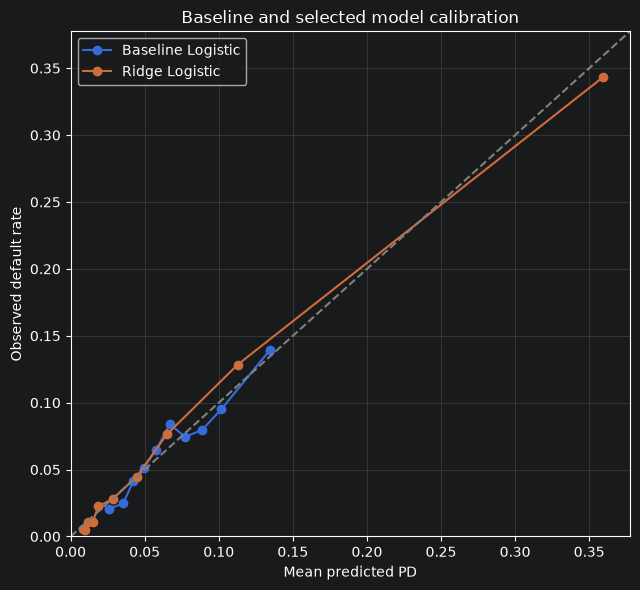

Saved calibration comparison to ../reports/figures/06_calibration_comparison.png
Saved selected model package to ../models/advanced_pd_model.pkl


In [6]:
if selected_name == "Baseline Logistic":
    selected_pack = {
        "kind": "baseline",
        "model_name": selected_name,
        "seed": SEED,
        "baseline_pack": base_pack,
    }
elif selected_name == "Nonlinear Logistic":
    selected_pack = {
        "kind": "nonlinear_mle",
        "model_name": selected_name,
        "seed": SEED,
        "terms": terms,
        "scale": scale_adv,
        "features": list(train_adv.columns),
        "coef": adv_fit.params.to_numpy(),
    }
else:
    reg_kind = {
        "Ridge Logistic": "ridge",
        "Lasso Logistic": "lasso",
        "Elastic Net Logistic": "elastic_net",
    }[selected_name]
    reg_search = tune_reg(train_feat, train_y, reg_kind, seed=SEED)
    selected_pack = {
        "kind": reg_kind,
        "model_name": selected_name,
        "seed": SEED,
        "best_c": reg_search.best_params_["logit__C"],
        "pipeline": reg_search.best_estimator_,
    }

selected_pd = predict_model(hold_feat, selected_pack)
selected_metrics = discrimination_metrics(hold_y, selected_pd)
selected_metrics["cal_gap"] = cal_gap(hold_y, selected_pd)
hold_tab = pd.DataFrame([
    {"model": "Baseline Logistic", **base_metrics,
     "cal_gap": cal_gap(hold_y, base_pd)},
    {"model": selected_name, **selected_metrics},
])
print(f"Selected model kind: {selected_pack['kind']}")
if "best_c" in selected_pack:
    print(f"Selected C: {selected_pack['best_c']}")
display(hold_tab.round(4))

cal_base = calibration_table(hold_y, base_pd)
cal_sel = calibration_table(hold_y, selected_pd)
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(
    cal_base["mean_predicted_pd"], cal_base["actual_default_rate"],
    marker="o", label="Baseline Logistic",
)
ax.plot(
    cal_sel["mean_predicted_pd"], cal_sel["actual_default_rate"],
    marker="o", label=selected_name,
)
cal_max = max(
    cal_base["mean_predicted_pd"].max(),
    cal_base["actual_default_rate"].max(),
    cal_sel["mean_predicted_pd"].max(),
    cal_sel["actual_default_rate"].max(),
) * 1.05
ax.plot([0, cal_max], [0, cal_max], linestyle="--", color="gray")
ax.set_xlim(0, cal_max)
ax.set_ylim(0, cal_max)
ax.set_xlabel("Mean predicted PD")
ax.set_ylabel("Observed default rate")
ax.set_title("Baseline and selected model calibration")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
os.makedirs("../reports/figures", exist_ok=True)
fig.savefig(FIG_PATH, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved calibration comparison to {FIG_PATH}")

os.makedirs("../models", exist_ok=True)
with open(OUT_PATH, "wb") as model_file:
    pickle.dump(selected_pack, model_file)
print(f"Saved selected model package to {OUT_PATH}")

## Conclusion / Findings / Next step

The expanded logistic models materially improve on the baseline in five-fold cross-validation. The baseline mean AUC is 0.6538, compared with 0.8554 for the unpenalized nonlinear model and 0.8546 for Ridge. Ridge also lowers mean Brier score from 0.06158 to 0.05071 and calibration gap from 0.0068 to 0.0048. The selection rule chooses Ridge because it is within one standard error of the top AUC and its probability metrics are comparable, while its L2 penalty provides some shrinkage in the expanded design. The final training-partition search selected C=1000.

On the reserved seed 47 holdout, Ridge reaches AUC 0.8528, Gini 0.7056, KS 0.5527, PR-AUC 0.3673, and Brier score 0.0513. The baseline holdout AUC is 0.6484 and Brier score is 0.0618. This is a large internal improvement; it should be confirmed on a separate time-based or external sample before operational use.

The unpenalized expanded fit converges, and its likelihood-ratio test strongly favors the added terms (p<0.001). However, the expanded design is highly collinear: 16 predictors have VIF above 10, the maximum VIF is 17,199.5, and the condition number is 377. Thousands of rows exceed the Cook’s-distance screening threshold, so coefficient-level interpretation and influence diagnostics need care.

The selected model and preprocessing are saved in `models/advanced_pd_model.pkl`; the calibration comparison is saved in `reports/figures/06_calibration_comparison.png`. Next, Notebook 07 can develop the traditional scorecard and compare its trade-offs with this selected model.